In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Data loading
df = pd.read_csv('../data/processed/otomoto_all_data_cleaned.csv')

# --- QUICK CLEANING ---
df = df[(df['price'] > 1000) & (df['price'] < 2000000)]
df = df[df['year'] > 1990]

# --- FEATURE DEFINITION ---
NUM_FEATURES = ['year', 'mileage_km', 'power_hp']
CAT_FEATURES = ['brand', 'model', 'fuel_type', 'gearbox', 'drive', 'location_voivodeship', 'origin']
# Ensure these columns exist in CSV (even if empty)
BOOL_FEATURES = ['accident_free', 'first_owner', 'damaged']

# FIX 1: Adding BOOL_FEATURES to X!
# We must ensure we select only those columns that actually exist in df
available_bools = [col for col in BOOL_FEATURES if col in df.columns]
if len(available_bools) < len(BOOL_FEATURES):
    print(f"Warning: Some binary columns were not found. Using only: {available_bools}")

X = df[NUM_FEATURES + CAT_FEATURES + available_bools]
y = df['price']

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} cars, testing on {X_test.shape[0]}")

# ==============================================================================
# 2. TRANSFORMER DEFINITION (Building blocks first!)
# ==============================================================================

# A. Numerical
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# B. Categorical
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

# C. Binary (Helper function)
def fill_binary(x):
    # Replaces NaN with 0, and anything else with 1
    return x.notna().astype(int)

bool_transformer = FunctionTransformer(fill_binary)

# ==============================================================================
# 3. ASSEMBLING THE PREPROCESSOR (Building the house)
# ==============================================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, NUM_FEATURES),
        ('cat', cat_transformer, CAT_FEATURES),
        ('bool', bool_transformer, available_bools) # FIX 2: Using available_bools
    ])

# ==============================================================================
# 4. MODEL
# ==============================================================================

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

# ==============================================================================
# 5. TRAINING
# ==============================================================================

print("Starting model training...")
model.fit(X_train, y_train)
print("Model trained!")

# Prediction
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nMODEL RESULTS:")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} PLN")
print(f"RMSE: {rmse:.2f} PLN")

# Sample results
print("\nSample predictions vs Reality:")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head(5)
results['Difference %'] = ((results['Predicted'] - results['Actual']) / results['Actual']) * 100
display(results.round(2))

Training on 140949 cars, testing on 35238
Starting model training...
Model trained!

MODEL RESULTS:
R2 Score: 0.9298
MAE: 10849.61 PLN
RMSE: 30711.36 PLN

Sample predictions vs Reality:


,Actual,Predicted,Difference %
119626,322998.0,303066.47,-6.17
92956,35000.0,33935.92,-3.04
55290,36900.0,38786.16,5.11
137527,119900.0,64197.06,-46.46
115888,56900.0,52122.60,-8.40


In [2]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results['Error_Pct'] = ((results['Predicted'] - results['Actual']) / results['Actual']) * 100

bad_prediction = results[ (results['Actual'] == 119900) & (results['Error_Pct'] < -40) ]

print(f"Found {len(bad_prediction)} bad prediction cases.")

if not bad_prediction.empty:
    error_indices = bad_prediction.index
    
    cols_to_check = ['brand', 'model', 'version', 'year', 'power_hp', 'fuel_type', 'drive', 'description']
    
    available_cols = [c for c in cols_to_check if c in df.columns]
    
    display(df.loc[error_indices, available_cols])
else:
    print("Unable to find any matching cases.")

Found 2 bad prediction cases.


,brand,model,version,year,power_hp,fuel_type,drive,description
137527,Volkswagen,Multivan,NaN,2011.0,180.0,Diesel,4x4 (dołączany automatycznie),Doinwestowany Przeczytaj Opis\nVW Multivan\n2....
847,Porsche,Cayenne,NaN,2019.0,340.0,Benzyna,NaN,"Witam,\nna sprzedaż posiadam Porsche Cayenne 3..."


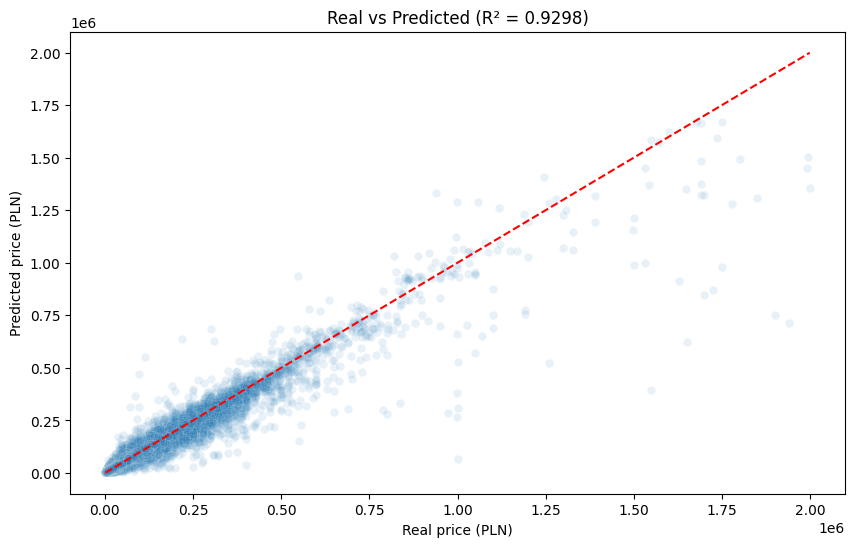

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.1)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Real price (PLN)')
plt.ylabel('Predicted price (PLN)')
plt.title(f'Real vs Predicted (R² = {r2:.4f})')
plt.show()

In [4]:
import joblib
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

joblib.dump(model, models_dir / 'random_forest_v1.joblib')

print(f"Model saved: {models_dir / 'random_forest_v1.joblib'}")

Model saved: ..\models\random_forest_v1.joblib
